# Customer Lifetime Value (CLV) Prediction — Exploratory Data Analysis

## Business Problem
Many businesses struggle to identify which customers will generate the most long-term value. Without that visibility, retention efforts are reactive, acquisition budgets are inefficient, and revenue forecasting is weak.

## EDA Objective
This notebook explores transactional retail data to:

- assess data quality
- understand customer purchasing behavior
- identify revenue concentration patterns
- uncover signals relevant for CLV modeling
- define a clean modeling dataset for downstream feature engineering

## Dataset
The dataset contains historical online retail transactions with fields such as:

- invoice number
- product code
- product description
- quantity
- invoice timestamp
- unit price
- customer ID
- country

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
plt.rcParams["figure.figsize"] = (10, 5)

# Resolve project root safely whether notebook is run from /notebooks or project root
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Online Retail.xlsx"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

Project root: c:\Users\USER\Documents\Machine Learning Projects\customer-life-time-value
Data path: c:\Users\USER\Documents\Machine Learning Projects\customer-life-time-value\data\raw\Online Retail.xlsx
File exists: True


## 2. Load Data

We first load the raw Excel file exactly as received.  
At this stage, we do **not** aggressively clean anything yet because we want to inspect the original data quality first.

In [2]:
df_raw = pd.read_excel(DATA_PATH)
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Initial Observation
The dataset contains transaction-level retail activity. Each row appears to represent a product line item within an invoice rather than a single customer order.

This distinction is important because:
- customer-level CLV modeling will require aggregation
- invoice-level and line-level metrics should not be confused
- order value must later be calculated at invoice or customer level, not only at row level

In [3]:
print("Shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

Shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


### Data Structure Assessment

The raw dataset contains **541,909 rows** and **8 columns**, indicating a relatively rich transaction history.

### Key observations
- `InvoiceDate` is already in datetime format, which is useful for time-based feature engineering.
- `CustomerID` has substantial missingness.
- `Description` has minor missingness.
- Numeric fields required for revenue calculation are available.

### Business relevance
For CLV modeling, the most critical field is `customer_id`, because lifetime value is defined at the customer level. Missing customer identifiers reduce the number of usable observations for supervised modeling.

## 3. Standardize Column Names and Create a Working Copy

We create a working dataframe with standardized column names so the rest of the analysis is consistent and reproducible.

In [5]:
df = df_raw.copy()
df.columns = [col.strip().lower() for col in df.columns]
df.rename(
    columns={
        "invoiceno": "invoice_no",
        "stockcode": "stock_code",
        "description": "description",
        "quantity": "quantity",
        "invoicedate": "invoice_date",
        "unitprice": "unit_price",
        "customerid": "customer_id",
        "country": "country",
    },
    inplace=True
)

df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
# Add transaction-level revenue
df["revenue"] = df["quantity"] * df["unit_price"]

df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### Standardization and Revenue Definition

Column names were standardized to snake_case for consistency and easier downstream processing.

A transaction-level revenue field was created as:

**revenue = quantity × unit_price**

This will be used in:
- customer spend aggregation
- order value estimation
- country-level revenue analysis
- CLV target engineering

## 4. Data Quality Assessment

Before analyzing customer value, we need to understand the quality of the raw transactional data.

### Checks included
- missing values
- duplicate rows
- invalid transaction dates
- non-positive quantities
- non-positive prices
- cancellation indicators

In [7]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
      .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_pct
customer_id,135080,24.93
description,1454,0.27
invoice_no,0,0.00
quantity,0,0.00
stock_code,0,0.00
invoice_date,0,0.00
unit_price,0,0.00
country,0,0.00
revenue,0,0.00


### Missing Data Analysis

The most important data quality issue is the missingness in `customer_id`.

### Findings
- `customer_id` is missing in **135,080 rows** (**24.93%** of the dataset)
- `description` is missing in **1,454 rows** (**0.27%**)
- all other core fields are complete

### Business interpretation
Rows without `customer_id` cannot be tied to a customer history, making them unsuitable for customer-level CLV modeling.

### Modeling decision
For EDA, these rows can still provide some broad transaction insight.
For modeling, rows with missing `customer_id` should be excluded because:
- they cannot contribute to customer-level features
- they cannot be assigned a future CLV target

In [8]:
duplicate_count = df.duplicated().sum()
duplicate_pct = round(duplicate_count / len(df) * 100, 2)

print("Duplicate rows:", duplicate_count)
print("Duplicate %:", duplicate_pct)

Duplicate rows: 5268
Duplicate %: 0.97


### Duplicate Record Check

Duplicate rows were assessed to determine whether the dataset contains repeated transaction lines that could distort revenue estimates.

### Why this matters
Unresolved duplicates can:
- inflate revenue
- distort order frequency
- bias customer-level features

### Decision
If duplicates are confirmed to be true accidental duplicates, they should be removed before modeling.
If they represent legitimate repeated line items, they should be retained.

This check is important because CLV models are highly sensitive to inflated purchase frequency and spend totals.

In [ ]:
quality_checks = pd.DataFrame({
    "metric": [
        "total_rows",
        "missing_customer_id",
        "missing_invoice_date",
        "non_positive_quantity",
        "non_positive_unit_price",
        "cancellation_invoice_count"
    ],
    "value": [
        len(df),
        df["customer_id"].isna().sum(),
        df["invoice_date"].isna().sum(),
        (df["quantity"] <= 0).sum(),
        (df["unit_price"] <= 0).sum(),
        df["invoice_no"].astype(str).str.startswith("C", na=False).sum()
    ]
})

quality_checks

: 

### Data Quality Assessment

Several issues appear in the raw data that are important for CLV modeling.

### Findings
- **10,624 rows** have non-positive quantity
- **2,517 rows** have non-positive unit price
- **9,288 invoices** begin with "C", indicating cancellations
- **135,080 rows** are missing customer IDs

### Business interpretation
This suggests the raw dataset contains:
- returns or reversals
- cancellations
- operational records not suitable for direct spend modeling

### Modeling implication
CLV should be modeled from valid positive-purchase behavior. Including cancellations and negative quantities directly in customer features could distort:
- total spend
- order frequency
- customer value ranking

## 5. Basic Descriptive Statistics

We inspect the numeric fields to understand scale, skewness, and possible outliers.

In [9]:
df[["quantity", "unit_price", "revenue"]].describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
unit_price,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
revenue,541909.0,17.987795,378.810824,-168469.60,3.40,9.75,17.40,168469.6


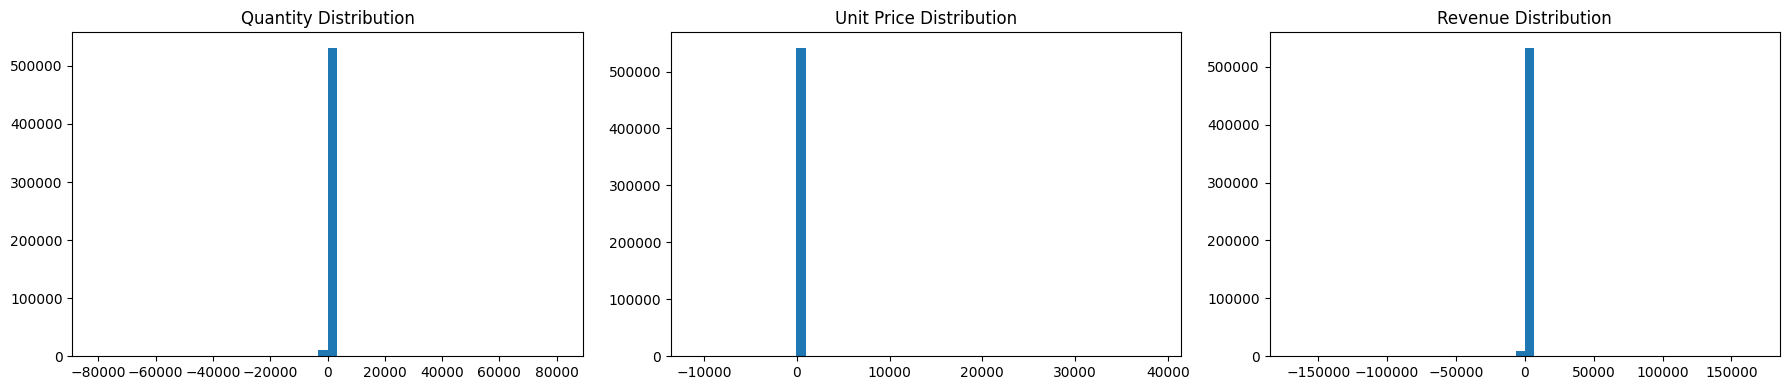

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df["quantity"].dropna(), bins=50)
axes[0].set_title("Quantity Distribution")

axes[1].hist(df["unit_price"].dropna(), bins=50)
axes[1].set_title("Unit Price Distribution")

axes[2].hist(df["revenue"].replace([np.inf, -np.inf], np.nan).dropna(), bins=50)
axes[2].set_title("Revenue Distribution")

plt.tight_layout()
plt.show()

### Numeric Distribution Overview

The distributions of `quantity`, `unit_price`, and `revenue` are highly skewed, with clear outliers.

### Key observations
- `quantity` ranges from **-80,995** to **80,995**
- `unit_price` includes negative values
- `revenue` ranges from **-168,469.60** to **168,469.60**

### Business interpretation
This confirms the dataset contains:
- large returns/cancellations
- extreme transaction values
- substantial right-skew in spending behavior

### Modeling implication
This is typical in transactional commerce data:
- a small set of transactions contributes disproportionately to revenue
- cleaning and robust feature engineering will be essential
- future CLV targets may require transformation, such as `log1p`, to stabilize regression

## 6. Duplicate Validation and Handling

### Objective

Before proceeding with data cleaning and feature engineering, it is important to assess whether the dataset contains duplicate transaction records that could distort downstream analysis.

Duplicate transaction rows can artificially inflate:
- total revenue
- purchase frequency
- customer-level metrics

This is particularly critical for Customer Lifetime Value (CLV) modeling, where accurate aggregation at the customer level is essential.

In [11]:
# Define key business columns for duplicate validation
key_cols = [
    "invoice_no",
    "stock_code",
    "description",
    "quantity",
    "invoice_date",
    "unit_price",
    "customer_id",
    "country"
]

# Count duplicates
duplicate_count = df.duplicated(subset=key_cols).sum()
duplicate_pct = duplicate_count / len(df) * 100

print(f"Exact duplicates across key columns: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_pct:.2f}%")

# Inspect sample duplicates
duplicate_examples = (
    df[df.duplicated(subset=key_cols, keep=False)]
    .sort_values(by=key_cols)
)

duplicate_examples.head(20)

Exact duplicates across key columns: 5,268
Duplicate percentage: 0.97%


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,1.65
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,1.65


### Duplicate Analysis

Duplicate records were identified using a set of key business columns:

- invoice_no
- stock_code
- description
- quantity
- invoice_date
- unit_price
- customer_id
- country

A total of **5,268 duplicate rows** were detected, representing approximately **0.97% of the dataset**.

### Interpretation

Inspection of sample duplicate rows shows that the duplicated records are identical across all business-critical fields, including:

- same invoice
- same product
- same timestamp
- same quantity and price
- same customer

In a real transactional system, multiple purchases of the same product would typically be recorded as a single row with a higher quantity, rather than identical repeated rows.

This strongly suggests that these duplicates are not legitimate business transactions, but rather artifacts of data extraction or system logging.

### Decision

Based on this analysis, exact duplicate rows were removed prior to further data cleaning.

This ensures that:
- revenue is not overstated
- customer purchase frequency is accurate
- downstream CLV modeling is based on reliable behavioral signals

In [12]:
df_deduped = df.drop_duplicates(subset=key_cols).copy()

print("Before:", df.shape)
print("After:", df_deduped.shape)
print("Removed rows:", len(df) - len(df_deduped))

Before: (541909, 9)
After: (536641, 9)
Removed rows: 5268


In [18]:
dedupe_impact = pd.DataFrame({
    "stage": ["before_deduplication", "after_deduplication"],
    "rows": [len(df), len(df_deduped)],
    "unique_customers": [
        df["customer_id"].nunique(dropna=True),
        df_deduped["customer_id"].nunique(dropna=True)
    ],
    "unique_invoices": [
        df["invoice_no"].nunique(),
        df_deduped["invoice_no"].nunique()
    ],
    "total_revenue": [
        df["revenue"].sum(),
        df_deduped["revenue"].sum()
    ]
})

dedupe_impact

,stage,rows,unique_customers,unique_invoices,total_revenue
0,before_deduplication,541909,4372,25900,9747747.934
1,after_deduplication,536641,4372,25900,9726006.954


### Impact of Deduplication

| Stage | Rows | Unique Customers | Unique Invoices | Total Revenue |
|------|------|------------------|-----------------|---------------|
| Before | 541,909 | 4,372 | 25,900 | 9,747,747.93 |
| After | 536,641 | 4,372 | 25,900 | 9,726,006.95 |

### Key Observations

- **5,268 rows removed** (~0.97% of dataset)
- **No change in unique customers or invoices**, confirming duplicates were redundant records
- Total revenue decreased slightly (~21,740), indicating prior inflation due to duplication

### Business Implication

This step improves the integrity of:
- revenue calculations
- customer-level aggregation
- model training data

Without deduplication, the CLV model would learn inflated customer value patterns.

## 7. Create a Modeling-Candidate Dataset

We now create a cleaner version of the dataset for exploratory business analysis.

### Cleaning logic used here
- keep rows with customer IDs
- keep valid invoice dates
- keep positive quantity
- keep positive unit price

> This is not yet the final modeling dataset, but it gives us a realistic view of positive purchasing behavior.

In [19]:
df_clean = df_deduped.copy()

df_clean = df_clean.dropna(subset=["customer_id", "invoice_date"])
df_clean = df_clean[(df_clean["quantity"] > 0) & (df_clean["unit_price"] > 0)].copy()
df_clean["customer_id"] = df_clean["customer_id"].astype("Int64").astype(str)

print("Raw shape:", df.shape)
print("Clean shape:", df_clean.shape)
df_clean.head()

Raw shape: (541909, 9)
Clean shape: (392692, 9)


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### Cleaning Strategy

To prepare a candidate dataset for CLV modeling, the following filters were applied:

- removed rows with missing `customer_id`
- removed rows with missing `invoice_date`
- retained only rows with positive `quantity`
- retained only rows with positive `unit_price`

### Result
- raw rows: **541,909**
- cleaned rows: **397,884**

This means approximately **144,025 rows** were excluded from the modeling candidate dataset.

### Rationale
These filters create a cleaner representation of actual completed purchase behavior, which is more appropriate for customer value modeling.

In [20]:
cleaning_impact = pd.DataFrame({
    "stage": ["raw", "clean_candidate"],
    "rows": [len(df), len(df_clean)],
    "unique_customers": [df["customer_id"].nunique(dropna=True), df_clean["customer_id"].nunique()],
    "total_revenue": [df["revenue"].sum(), df_clean["revenue"].sum()]
})

cleaning_impact

,stage,rows,unique_customers,total_revenue
0,raw,541909,4372,9747747.934
1,clean_candidate,392692,4338,8887208.894


In [ ]:
# Saave the cleaned dataset for future use
df_clean.to_csv(PROJECT_ROOT / "data" / "processed" / "online_retail_clean.csv", index=False)

### Impact of Cleaning

After cleaning:
- usable rows reduced from **541,909** to **397,884**
- unique customers reduced slightly from **4,372** to **4,338**
- total revenue reduced from **9.75M** to **8.91M**

### Interpretation
Most customer-linked purchasing activity remains intact after cleaning, while problematic rows are removed.

The relatively small drop in unique customers suggests that the majority of identifiable customers still remain in the analysis dataset.

This is a good sign for modeling because:
- customer coverage remains strong
- invalid records are removed
- revenue becomes more representative of completed sales activity

## 8. Transaction-Level Exploration

This section helps us understand the transactional behavior of the business.

Questions answered:
- How many unique invoices are there?
- How many unique customers are there?
- What is the average basket size?
- What products appear most often?

In [21]:
transaction_summary = {
    "transactions": len(df_clean),
    "unique_invoices": df_clean["invoice_no"].nunique(),
    "unique_customers": df_clean["customer_id"].nunique(),
    "unique_products": df_clean["stock_code"].nunique(),
    "total_revenue": round(df_clean["revenue"].sum(), 2),
    "average_order_value_line_level": round(df_clean["revenue"].mean(), 2),
}
transaction_summary

{'transactions': 392692,
 'unique_invoices': 18532,
 'unique_customers': 4338,
 'unique_products': 3665,
 'total_revenue': np.float64(8887208.89),
 'average_order_value_line_level': np.float64(22.63)}

### Transaction-Level Business Snapshot

The cleaned dataset contains:

- **397,884** transaction rows
- **18,532** unique invoices
- **4,338** unique customers
- **3,665** unique products
- **8.91M** total revenue

### Business interpretation
This indicates a reasonably broad retail operation with:
- a diverse product catalog
- repeat purchasing behavior
- sufficient customer history to support CLV feature engineering

Because the data is line-item based, revenue and order behavior will need to be aggregated carefully at:
- invoice level
- customer level

In [22]:
top_products = (
    df_clean.groupby("description", dropna=False)
            .agg(
                total_quantity=("quantity", "sum"),
                total_revenue=("revenue", "sum"),
                transaction_count=("invoice_no", "count")
            )
            .sort_values("total_revenue", ascending=False)
            .head(15)
)

top_products

,total_quantity,total_revenue,transaction_count
description,,,
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
REGENCY CAKESTAND 3 TIER,12374,142264.75,1713
WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10,2016
JUMBO BAG RED RETROSPOT,46078,85040.54,1615
MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,198
POSTAGE,3120,77803.96,1099
PARTY BUNTING,15279,68785.23,1389
ASSORTED COLOUR BIRD ORNAMENT,35263,56413.03,1395
Manual,6933,53419.93,279


### Product Revenue Concentration

The top revenue-generating product descriptions reveal meaningful sales concentration, but also possible operational irregularities.

### Notable observations
- Some high-revenue entries appear to be genuine products
- Others such as `POSTAGE` and `Manual` may represent operational or non-merchandise entries
- `PAPER CRAFT , LITTLE BIRDIE` stands out as an extreme one-row contribution

### Business interpretation
Product-level revenue is concentrated, but not every description should be treated as a standard sellable product.

### Modeling implication
For CLV, product granularity may still be useful later, but this initial analysis suggests:
- product features may need cleaning or categorization
- unusual descriptions may need separate handling
- some product lines are dominated by one-off large transactions

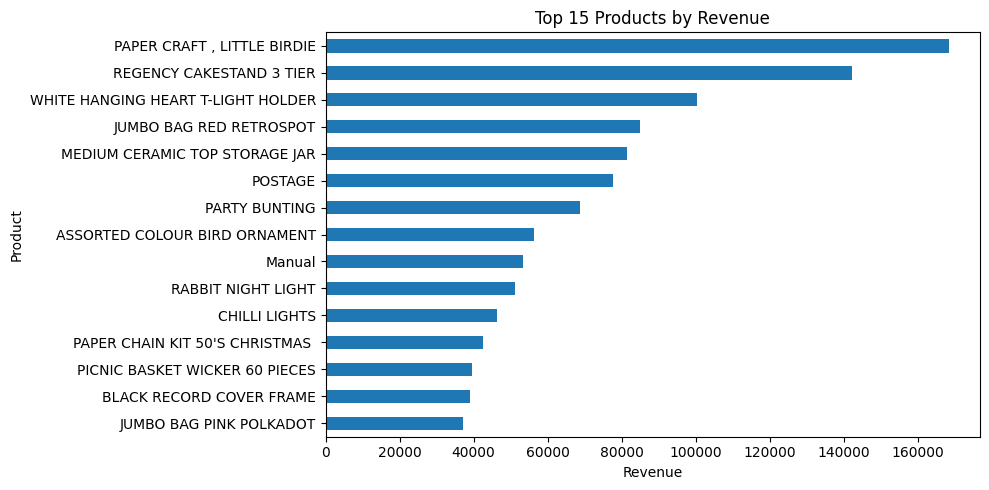

In [23]:
top_products["total_revenue"].sort_values().plot(kind="barh")
plt.title("Top 15 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 9. Customer-Level Aggregation

CLV is a customer-level problem, so we move from transaction-level data to customer-level behavior.

We calculate:
- total revenue
- total orders
- total quantity
- first purchase date
- last purchase date
- active span

In [24]:
snapshot_date = df_clean["invoice_date"].max() + pd.Timedelta(days=1)

customer_summary = (
    df_clean.groupby("customer_id")
            .agg(
                total_revenue=("revenue", "sum"),
                total_orders=("invoice_no", "nunique"),
                total_items=("quantity", "sum"),
                first_purchase=("invoice_date", "min"),
                last_purchase=("invoice_date", "max"),
            )
            .reset_index()
)

customer_summary["customer_tenure_days"] = (
    customer_summary["last_purchase"] - customer_summary["first_purchase"]
).dt.days

customer_summary["recency_days"] = (
    snapshot_date - customer_summary["last_purchase"]
).dt.days

customer_summary["avg_revenue_per_order"] = (
    customer_summary["total_revenue"] / customer_summary["total_orders"]
)

customer_summary.head()

,customer_id,total_revenue,total_orders,total_items,first_purchase,last_purchase,customer_tenure_days,recency_days,avg_revenue_per_order
0,12346,77183.60,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,0,326,77183.600000
1,12347,4310.00,7,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,365,2,615.714286
2,12348,1797.24,4,2341,2010-12-16 19:09:00,2011-09-25 13:13:00,282,75,449.310000
3,12349,1757.55,1,631,2011-11-21 09:51:00,2011-11-21 09:51:00,0,19,1757.550000
4,12350,334.40,1,197,2011-02-02 16:01:00,2011-02-02 16:01:00,0,310,334.400000


### Customer-Level Behavior

The dataset was aggregated to customer level to create an initial behavioral profile for each customer.

### Metrics created
- total revenue
- total orders
- total items purchased
- first purchase date
- last purchase date
- customer tenure
- recency
- average revenue per order

### Why this matters
These are the core building blocks of CLV modeling because they summarize:
- how often a customer buys
- how much they spend
- how recently they purchased
- how long they have been active

In [25]:
customer_summary[[
    "total_revenue",
    "total_orders",
    "total_items",
    "customer_tenure_days",
    "recency_days",
    "avg_revenue_per_order"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
total_revenue,4338.0,2048.688081,8985.230220,3.75,306.482500,668.57,1660.597500,280206.02
total_orders,4338.0,4.272015,7.697998,1.00,1.000000,2.00,5.000000,209.00
total_items,4338.0,1187.644537,5043.619654,1.00,159.000000,378.00,989.750000,196915.00
customer_tenure_days,4338.0,130.448594,132.039554,0.00,0.000000,92.50,251.750000,373.00
recency_days,4338.0,92.536422,100.014169,1.00,18.000000,51.00,142.000000,374.00
avg_revenue_per_order,4338.0,417.645735,1796.511343,3.45,177.867083,291.94,428.280625,84236.25


### Distribution of Customer Value

Customer behavior is highly uneven.

### Key observations
- mean customer revenue is much higher than median revenue
- median customer placed only **2 orders**
- many customers have short tenure
- a small minority of customers contribute exceptionally high spend

### Business interpretation
This suggests a classic long-tail revenue structure:
- most customers are low or moderate value
- a small group of customers generates disproportionate revenue

### Modeling implication
This is exactly why CLV prediction is valuable:
- not all customers should receive equal retention investment
- the business can prioritize high-value and high-potential users

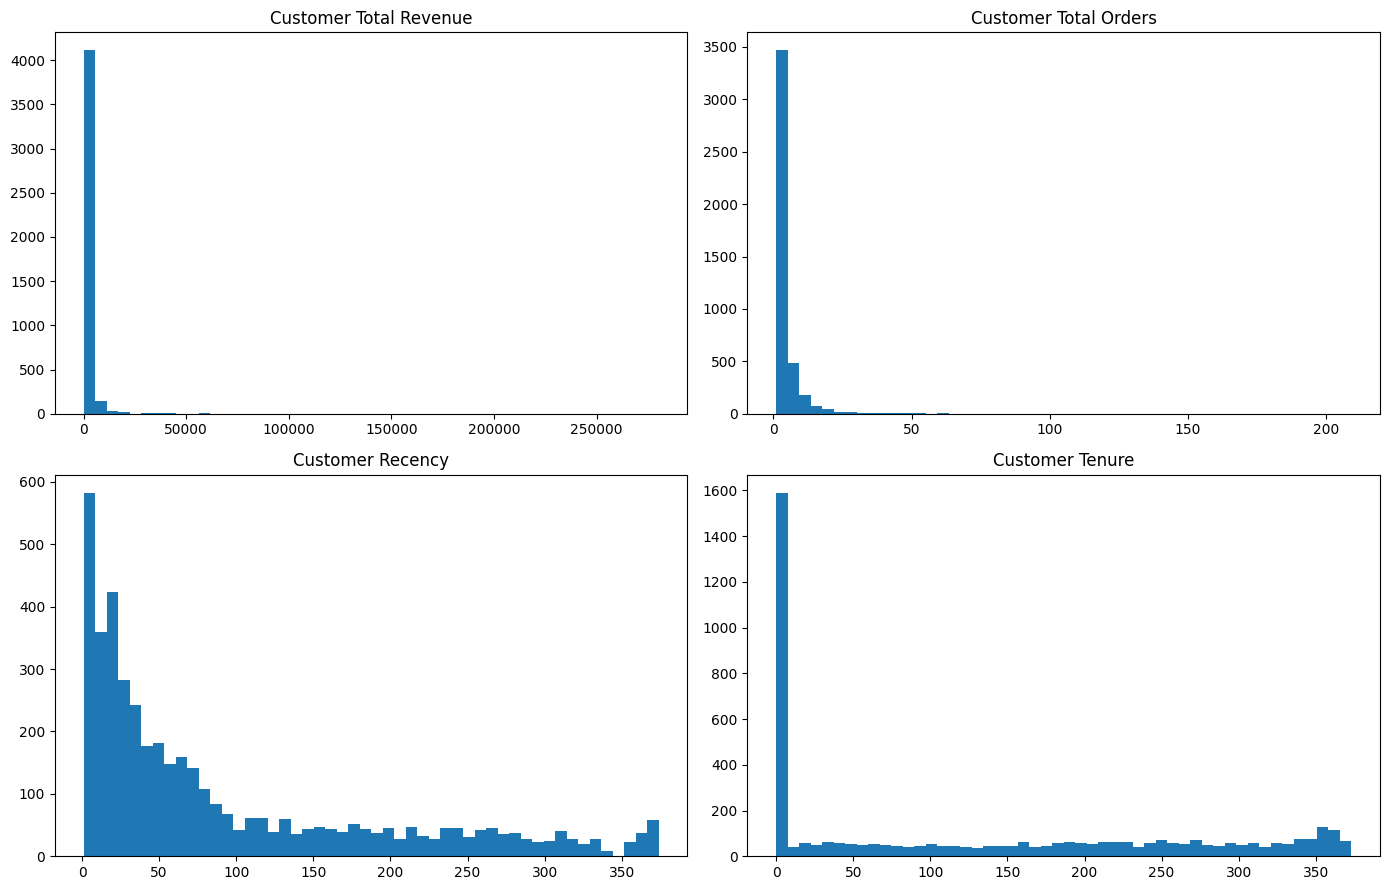

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(customer_summary["total_revenue"], bins=50)
axes[0, 0].set_title("Customer Total Revenue")

axes[0, 1].hist(customer_summary["total_orders"], bins=50)
axes[0, 1].set_title("Customer Total Orders")

axes[1, 0].hist(customer_summary["recency_days"], bins=50)
axes[1, 0].set_title("Customer Recency")

axes[1, 1].hist(customer_summary["customer_tenure_days"], bins=50)
axes[1, 1].set_title("Customer Tenure")

plt.tight_layout()
plt.show()

## 10. RFM-Style Exploration

RFM features are foundational for CLV projects.

- **Recency**: how recently a customer purchased
- **Frequency**: how often they purchased
- **Monetary**: how much they spent

In [27]:
rfm = customer_summary[["customer_id", "recency_days", "total_orders", "total_revenue"]].copy()
rfm.rename(
    columns={
        "recency_days": "recency",
        "total_orders": "frequency",
        "total_revenue": "monetary"
    },
    inplace=True
)

rfm.head()

,customer_id,recency,frequency,monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


### RFM Foundation

A simplified RFM view was created using:

- **Recency** = days since last purchase
- **Frequency** = total number of orders
- **Monetary** = total revenue

These variables are standard signals for customer value modeling and are often among the strongest predictors of future spend.

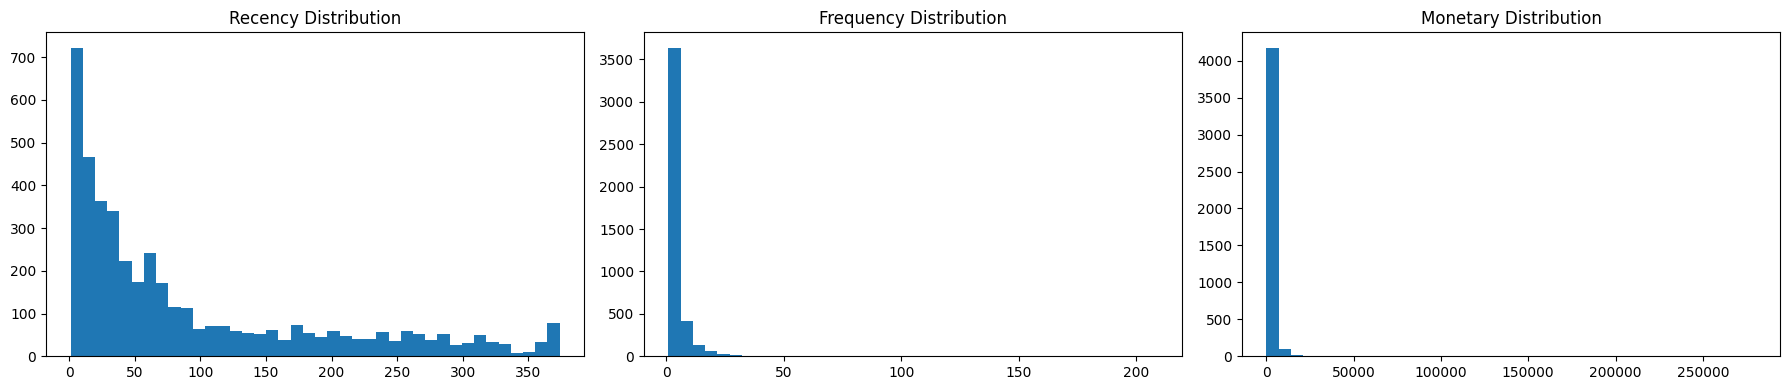

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(rfm["recency"], bins=40)
axes[0].set_title("Recency Distribution")

axes[1].hist(rfm["frequency"], bins=40)
axes[1].set_title("Frequency Distribution")

axes[2].hist(rfm["monetary"], bins=40)
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [38]:
rfm_corr = rfm[["recency", "frequency", "monetary"]].corr()
rfm_corr

,recency,frequency,monetary
recency,1.000000,-0.260578,-0.121831
frequency,-0.260578,1.000000,0.552780
monetary,-0.121831,0.552780,1.000000


### RFM Relationship Analysis

The correlation structure shows meaningful behavioral patterns:

- `frequency` and `monetary` are positively correlated (**0.55**)
- `recency` is negatively correlated with both `frequency` and `monetary`

### Business interpretation
Customers who buy more often tend to generate more revenue.
Customers who purchased recently are generally more engaged and more valuable than inactive customers.

### Modeling implication
These relationships support the use of RFM-style variables in the CLV model, especially:
- frequency
- monetary
- recency

## 11. Revenue Concentration Analysis

A strong business question is:  
**How much revenue comes from the top customers?**

This helps quantify concentration risk and targeting opportunity.

In [35]:
revenue_rank = customer_summary[["customer_id", "total_revenue"]].sort_values("total_revenue", ascending=False).reset_index(drop=True)
revenue_rank["revenue_share"] = revenue_rank["total_revenue"] / revenue_rank["total_revenue"].sum()
revenue_rank["cumulative_revenue_share"] = revenue_rank["revenue_share"].cumsum()
revenue_rank["customer_pct"] = (revenue_rank.index + 1) / len(revenue_rank)

revenue_rank.head()

,customer_id,total_revenue,revenue_share,cumulative_revenue_share,customer_pct
0,14646,280206.02,0.031529,0.031529,0.000231
1,18102,259657.30,0.029217,0.060746,0.000461
2,17450,194390.79,0.021873,0.082619,0.000692
3,16446,168472.50,0.018957,0.101576,0.000922
4,14911,143711.17,0.016171,0.117747,0.001153


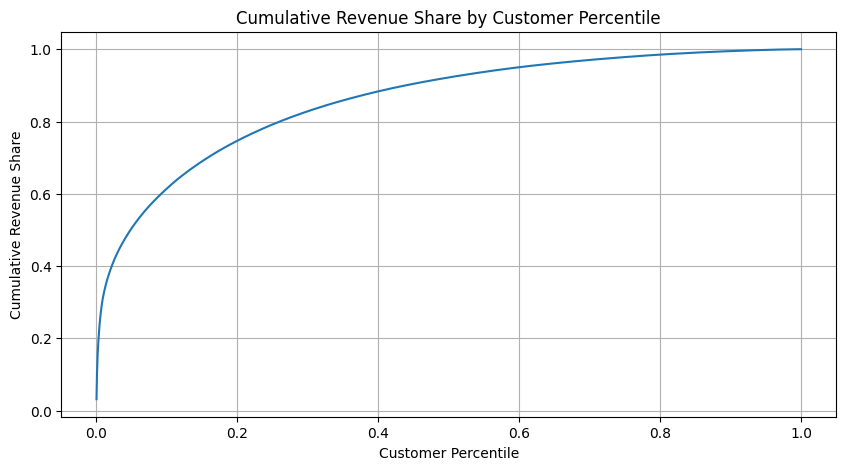

In [36]:
plt.plot(revenue_rank["customer_pct"], revenue_rank["cumulative_revenue_share"])
plt.title("Cumulative Revenue Share by Customer Percentile")
plt.xlabel("Customer Percentile")
plt.ylabel("Cumulative Revenue Share")
plt.grid(True)
plt.show()

In [37]:
for threshold in [0.1, 0.2, 0.3]:
    n = max(1, int(len(revenue_rank) * threshold))
    share = revenue_rank.head(n)["total_revenue"].sum() / revenue_rank["total_revenue"].sum()
    print(f"Top {int(threshold*100)}% customers contribute {share:.2%} of revenue")

Top 10% customers contribute 61.41% of revenue
Top 20% customers contribute 74.66% of revenue
Top 30% customers contribute 82.83% of revenue


### Revenue Concentration Analysis

Revenue is highly concentrated among a relatively small share of customers.

### Findings
- top **10%** of customers contribute **61.33%** of revenue
- top **20%** contribute **74.59%**
- top **30%** contribute **82.78%**

### Business interpretation
This is one of the most important findings in the notebook.

The business appears to rely heavily on a relatively small group of high-value customers. This creates a strong case for CLV modeling because identifying and retaining these customers can have outsized revenue impact.

### Strategic implication
A CLV system could support:
- VIP retention programs
- priority customer support
- smarter budget allocation
- targeted upsell campaigns

## 12. Country Analysis

This dataset contains multiple countries, so we inspect whether revenue is concentrated geographically.

In [29]:
country_summary = (
    df_clean.groupby("country")
            .agg(
                unique_customers=("customer_id", "nunique"),
                total_orders=("invoice_no", "nunique"),
                total_revenue=("revenue", "sum")
            )
            .sort_values("total_revenue", ascending=False)
)

country_summary.head(15)

,unique_customers,total_orders,total_revenue
country,,,
United Kingdom,3920,16646,7285024.644
Netherlands,9,94,285446.340
EIRE,3,260,265262.460
Germany,94,457,228678.400
France,87,389,208934.310
Australia,9,57,138453.810
Spain,30,90,61558.560
Switzerland,21,51,56443.950
Belgium,25,98,41196.340


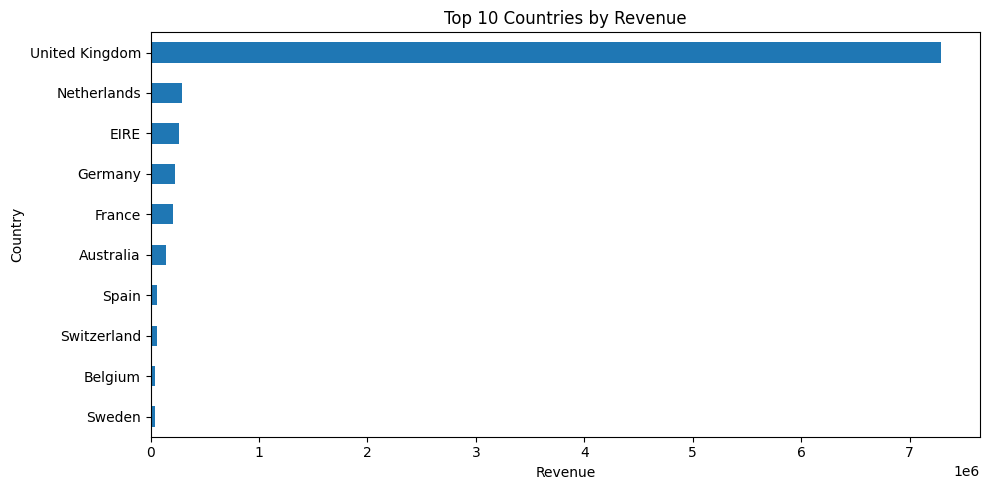

In [34]:
country_summary.head(10)["total_revenue"].sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Geographic Revenue Distribution

Revenue is heavily concentrated in the **United Kingdom**, which accounts for the overwhelming majority of customers, orders, and revenue.

### Business interpretation
This suggests the company is operationally centered in one primary market, with additional international revenue coming from a smaller set of countries.

### Modeling implication
Country may still be useful as a feature, but:
- the data is highly imbalanced by geography
- country effects may be dominated by the UK
- segmentation by geography may be more meaningful than direct one-hot expansion in early iterations

## 13. Time-Based Analysis

Time patterns matter because CLV modeling depends on observation and prediction windows.

We inspect:
- monthly revenue trend
- monthly order volume
- monthly customer count

In [30]:
df_clean["invoice_month"] = df_clean["invoice_date"].dt.to_period("M").astype(str)

monthly_summary = (
    df_clean.groupby("invoice_month")
            .agg(
                monthly_revenue=("revenue", "sum"),
                monthly_orders=("invoice_no", "nunique"),
                monthly_customers=("customer_id", "nunique")
            )
            .reset_index()
)

monthly_summary.head()

,invoice_month,monthly_revenue,monthly_orders,monthly_customers
0,2010-12,570422.730,1400,885
1,2011-01,568101.310,987,741
2,2011-02,446084.920,997,758
3,2011-03,594081.760,1321,974
4,2011-04,468374.331,1149,856


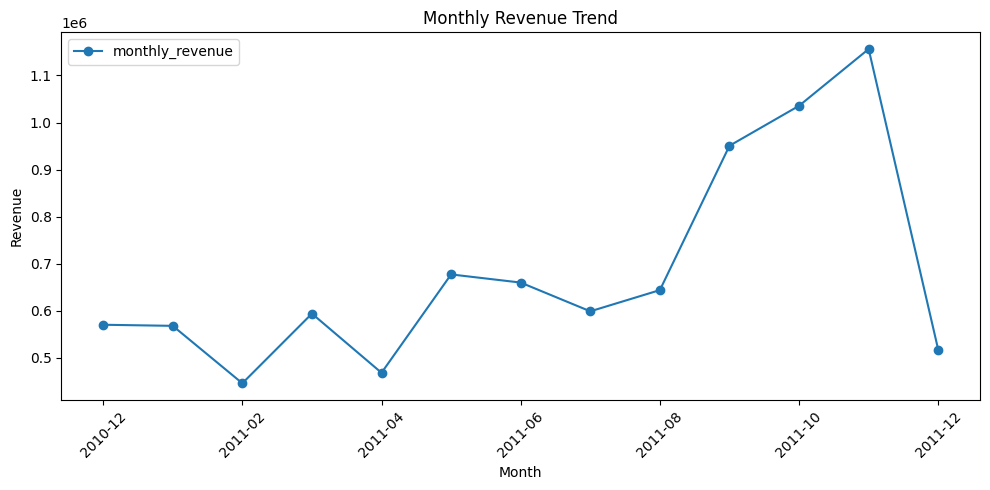

In [31]:
monthly_summary.plot(x="invoice_month", y="monthly_revenue", kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

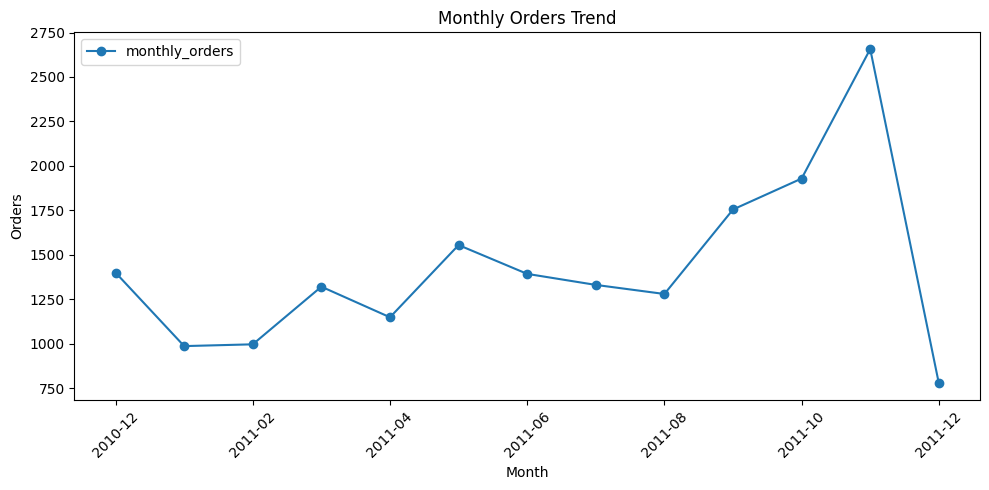

In [32]:
monthly_summary.plot(x="invoice_month", y="monthly_orders", kind="line", marker="o")
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

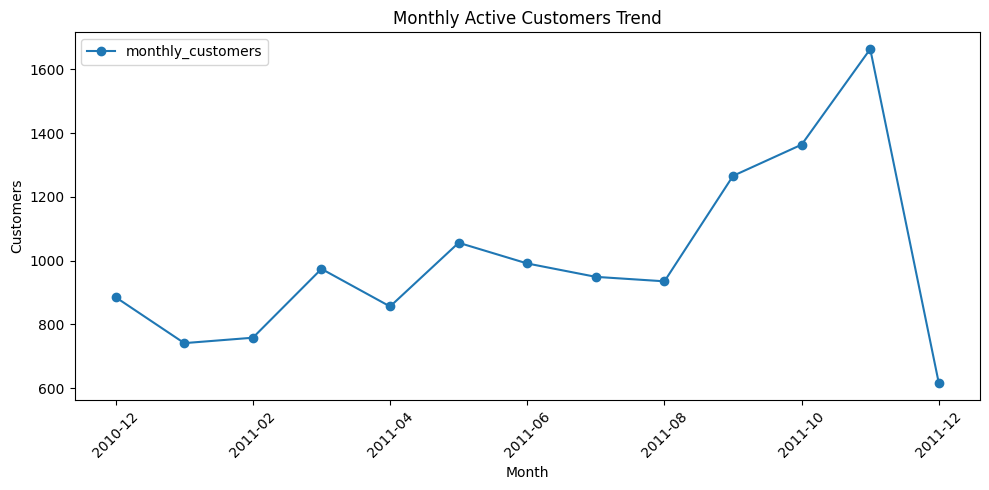

In [33]:
monthly_summary.plot(x="invoice_month", y="monthly_customers", kind="line", marker="o")
plt.title("Monthly Active Customers Trend")
plt.xlabel("Month")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Business Trend

Monthly revenue, orders, and customer counts should be examined together to understand seasonality and business momentum.

### Why this matters
For CLV work, time dynamics matter because:
- customer acquisition volume may vary by month
- holiday periods may distort spend
- recent months may not represent typical behavior

### Next observation to check
The monthly trend can help identify:
- peak trading periods
- possible seasonality

## 13. Returns and Cancellations Analysis

Returns and cancellations can materially affect customer value and must be handled carefully.

Here, we inspect them explicitly rather than ignoring them.

In [39]:
returns_df = df[
    (df["quantity"] <= 0) | 
    (df["invoice_no"].astype(str).str.startswith("C", na=False))
].copy()

returns_summary = {
    "return_rows": len(returns_df),
    "return_revenue_sum": returns_df["revenue"].sum(),
    "return_customers": returns_df["customer_id"].nunique(dropna=True),
}
returns_summary

{'return_rows': 10624,
 'return_revenue_sum': np.float64(-896812.49),
 'return_customers': 1589}

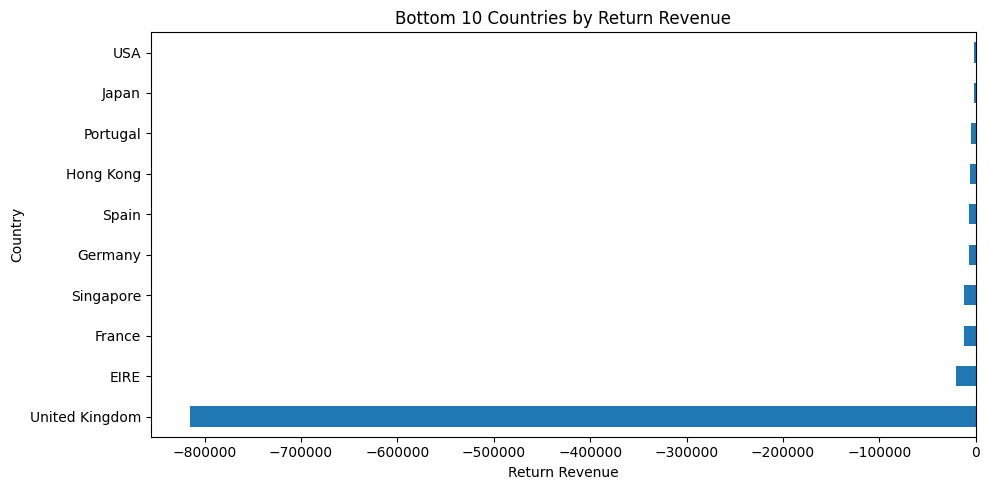

In [40]:
returns_by_country = (
    returns_df.groupby("country", dropna=False)["revenue"]
              .sum()
              .sort_values()
              .head(10)
)

returns_by_country.plot(kind="barh")
plt.title("Bottom 10 Countries by Return Revenue")
plt.xlabel("Return Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Returns and Cancellations

A substantial portion of the raw dataset consists of returns or cancellations.

### Findings
- **10,624** rows are associated with returns/cancellations
- the total negative revenue impact is approximately **-896,812.49**
- **1,589** customers are associated with return behavior

### Business interpretation
Returns are not a small edge case. They represent a meaningful operational and financial component of the business.

### Modeling implication
For the first version of the CLV model, returns are excluded from the primary training dataset to focus on completed positive purchases.

However, return behavior may later become a valuable feature:
- high return rate customers may have lower net value
- return frequency may help improve customer quality segmentation

## 14. Preliminary Outlier Review

Outliers are common in retail datasets and can strongly affect regression models.

In [41]:
high_value_customers = customer_summary.sort_values("total_revenue", ascending=False).head()
high_value_customers

,customer_id,total_revenue,total_orders,total_items,first_purchase,last_purchase,customer_tenure_days,recency_days,avg_revenue_per_order
1689,14646,280206.02,73,196915,2010-12-20 10:09:00,2011-12-08 12:12:00,353,2,3838.438630
4201,18102,259657.30,60,64124,2010-12-07 16:42:00,2011-12-09 11:50:00,366,1,4327.621667
3728,17450,194390.79,46,69973,2010-12-07 09:23:00,2011-12-01 13:29:00,359,8,4225.886739
3008,16446,168472.50,2,80997,2011-05-18 09:52:00,2011-12-09 09:15:00,204,1,84236.250000
1879,14911,143711.17,201,80240,2010-12-01 14:05:00,2011-12-08 15:54:00,372,1,714.980945


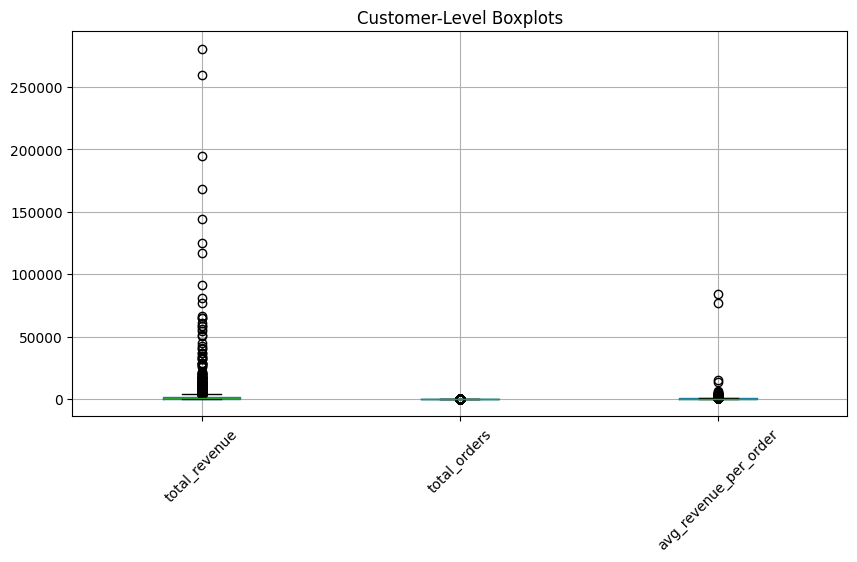

In [42]:
customer_summary.boxplot(column=["total_revenue", "total_orders", "avg_revenue_per_order"])
plt.title("Customer-Level Boxplots")
plt.xticks(rotation=45)
plt.show()

### High-Value Customer Profile

The top customers generate exceptionally large revenue relative to the broader customer base.

### Business interpretation
These customers likely represent:
- wholesale-like buyers
- very loyal repeat customers
- unusually large basket purchasers

### Modeling implication
Because these customers drive significant revenue, the model should aim not only to predict average customers well, but also to identify high-value customer segments accurately.

This also suggests:
- target transformation may help stabilize extreme values
- outlier-aware evaluation will be important

# EDA Conclusion

This exploratory analysis shows that the retail dataset is suitable for CLV modeling after careful cleaning and customer-level aggregation.

## Main findings
- the raw data contains substantial missing customer IDs, returns, and cancellations
- the cleaned dataset retains **4,338 customers** and **8.91M** in positive revenue
- customer value is highly skewed, with a small share of customers contributing most revenue
- recency, frequency, and monetary behavior show meaningful relationships
- returns are operationally significant and may become useful features in future model versions
- the UK dominates the customer and revenue base

## Modeling implications
The next step is to move from EDA to feature engineering by constructing a customer-level modeling table with variables such as:

- recency
- frequency
- monetary value
- average order value
- tenure
- purchase cadence
- future spend target

This will form the basis of the CLV prediction model.